### 1. Load Data & Exploratory Data Analysis (EDA)

In [8]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("D:\Code Scripts\AI_Projects\ML\heart failure prediction\data\heart.csv")

# Preview data
print(df.head())

# Informasi dataset
print(df.info())

# Statistik deskriptif
print(df.describe())

# Cek missing value
print(df.isnull().sum())

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age    

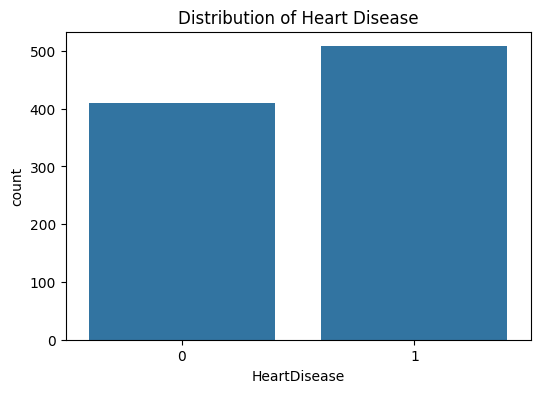

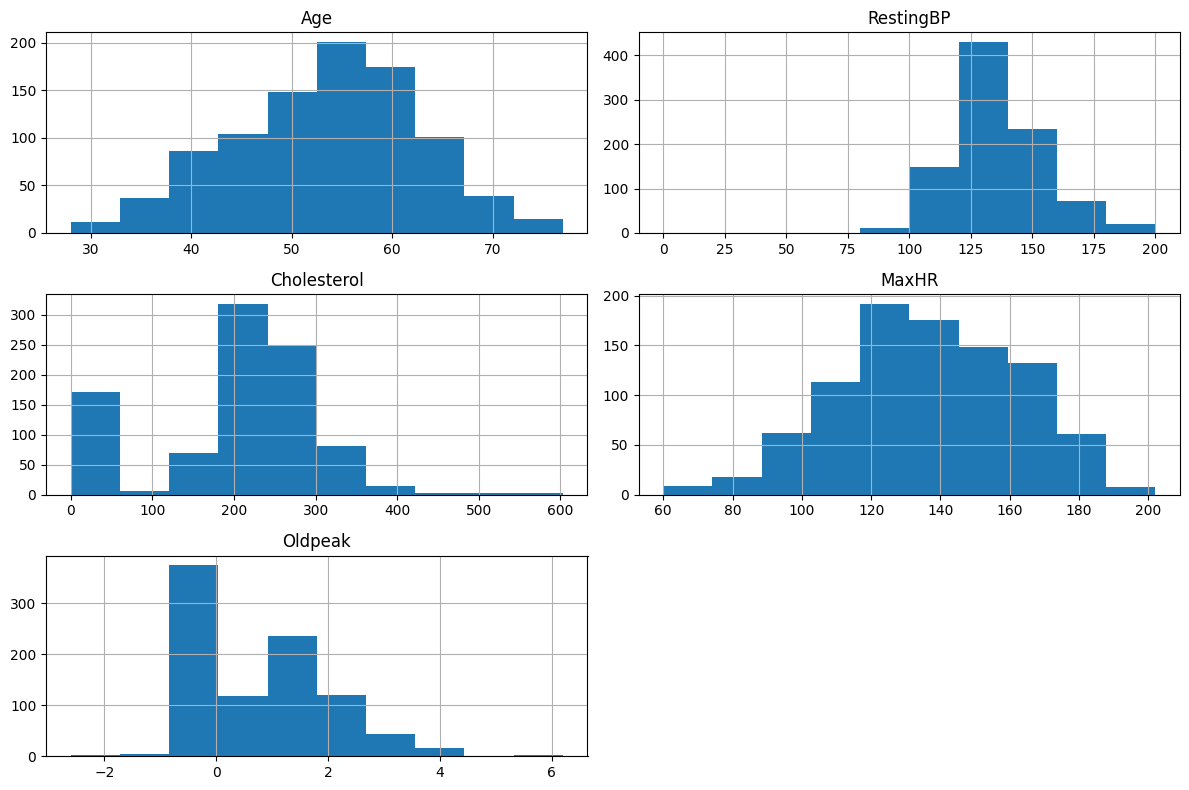

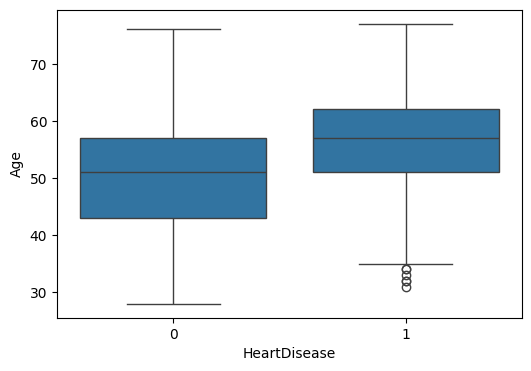

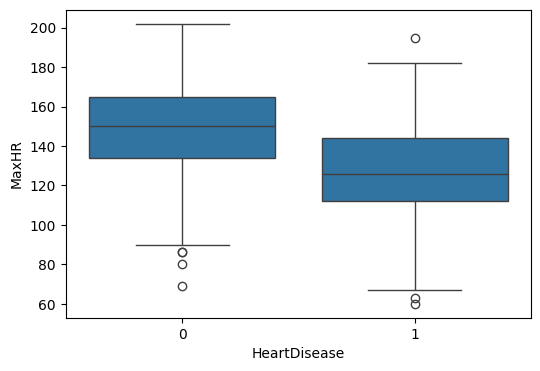

In [9]:
#Distribusi target variable
plt.figure(figsize=(6,4))
sns.countplot(x='HeartDisease', data=df)
plt.title("Distribution of Heart Disease")
plt.show()

#Distribusi Fitur Numerik
num_cols = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']

df[num_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

#Hubungan Feature dengan Target
plt.figure(figsize=(6,4))
sns.boxplot(x='HeartDisease', y='Age', data=df)
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='HeartDisease', y='MaxHR', data=df)
plt.show()

### 2. Data Preprocessing

In [1]:
!pip install imbalanced-learn


[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
# Import library preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

#Encoding Variabel Kategorikal
categorical_cols = ['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

#Pisahkan fitur dan target
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

#Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_smote).value_counts())

Before SMOTE: HeartDisease
1    406
0    328
Name: count, dtype: int64
After SMOTE: HeartDisease
1    406
0    406
Name: count, dtype: int64


### 3. Modeling

In [11]:
from sklearn.ensemble import ExtraTreesClassifier

model = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

model.fit(X_train_smote, y_train_smote)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9021739130434783
Precision: 0.8962264150943396
Recall   : 0.9313725490196079
F1 Score : 0.9134615384615384

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.87      0.89        82
           1       0.90      0.93      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184



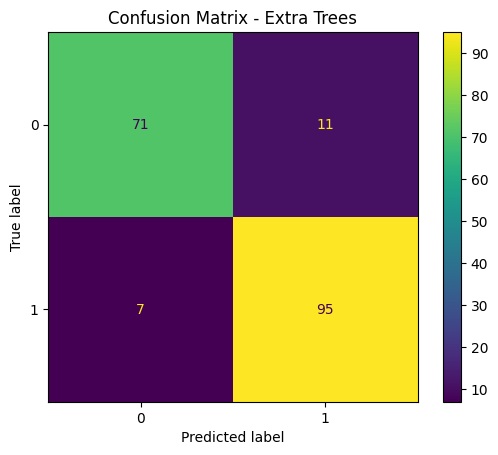

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Extra Trees")
plt.show()

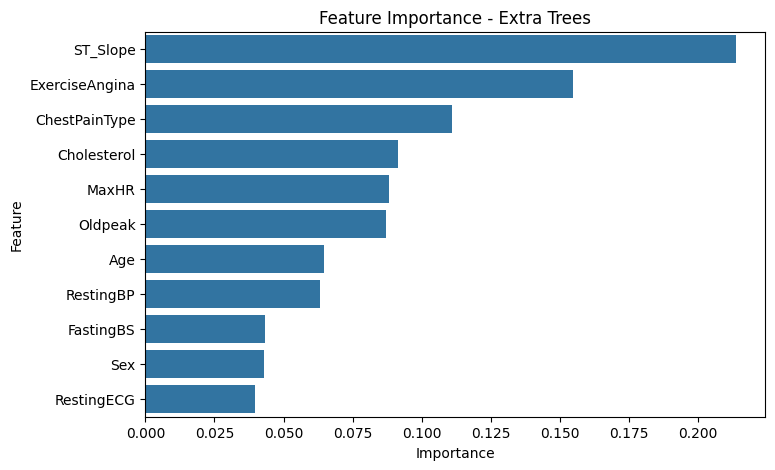

In [13]:
importances = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=feature_importance, x='Importance', y='Feature')
plt.title("Feature Importance - Extra Trees")
plt.show()

In [16]:
import os
import joblib

model_path = "D:\Code Scripts\AI_Projects\ML\heart failure prediction\models"

os.makedirs(model_path, exist_ok=True)

joblib.dump(model, os.path.join(model_path, "heart_failure_model.pkl"))
joblib.dump(scaler, os.path.join(model_path, "scaler.pkl"))
joblib.dump(encoders, os.path.join(model_path, "label_encoders.pkl"))

['D:\\Code Scripts\\AI_Projects\\ML\\heart failure prediction\\models\\label_encoders.pkl']